# Práctica 1. Perceptrón multicapa
### Redes Neuronales Artificiales y Aprendizaje Profundo
**José Luis Haro Díaz**

In [23]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [24]:
X = np.linspace(-50, 50, 100)
Y = 2.5 * X + 30
ruido = np.random.normal(0, 5, size=X.shape)
Y = Y + ruido

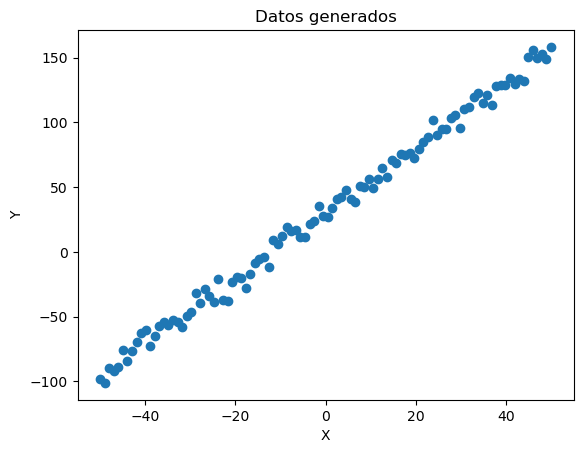

In [25]:
plt.scatter(X, Y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos generados")
plt.show()

In [26]:
X_norm = (X - np.mean(X)) / np.std(X)
Y_norm = (Y - np.mean(Y)) / np.std(Y)

In [ ]:
modelo = tf.keras.Sequential([
    tf.keras.Input(shape=[1]),     
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [28]:
modelo.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error'
)

In [29]:
print("Entrenamiento...")
historial = modelo.fit(X_norm, Y_norm, epochs=500, verbose=False)

Entrenamiento...


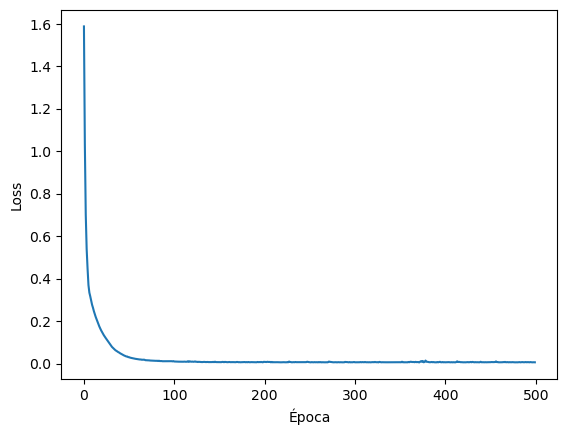

In [30]:
plt.xlabel("Época")
plt.ylabel("Loss")
plt.plot(historial.history["loss"])
plt.show()

In [31]:
print("Prediciendo...")
x_prueba = np.array([-40])
x_prueba_norm = (x_prueba - np.mean(X)) / np.std(X)

resultado_norm = modelo.predict(x_prueba_norm)

Prediciendo...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [32]:
resultado = resultado_norm * np.std(Y) + np.mean(Y)

print("Resultado:", resultado)

Resultado: [[-69.70846624]]


In [33]:
print("Pesos del modelo:")
for capa in modelo.layers:
    print(capa.get_weights())

Pesos del modelo:
[array([[-0.2804034 , -0.31280786,  0.49713397,  0.01640218,  0.5692499 ,
        -0.65699184, -0.07710017, -0.22444683]], dtype=float32), array([-0.1956115 ,  0.5358906 , -0.05914434, -0.14338261, -0.26781487,
        0.33185545, -0.15418784,  0.37628305], dtype=float32)]
[array([[-0.2410717 , -0.43681023, -0.47079217, -0.08838811, -0.11991292,
         0.3034262 , -0.4441288 ,  0.28053084],
       [-0.12264737, -0.15156814,  0.6046339 ,  0.88169646, -0.0269556 ,
         0.29632264, -0.14219648, -0.05963355],
       [-0.1616086 , -0.12523533, -0.05765714,  0.14490792, -0.42768896,
        -0.21057293, -0.29496458, -0.20520845],
       [ 0.07534218,  0.420752  ,  0.09274   , -0.19976264,  0.2908976 ,
         0.26907456,  0.424321  ,  0.15510473],
       [-0.02099448,  0.2647844 ,  0.00733468, -0.99117833,  0.2707223 ,
         0.37979138,  0.12858582,  0.08428127],
       [-0.4378226 , -0.20597276,  0.36011213,  0.41989818, -0.607814  ,
         0.46632025,  0.38704